In [3]:
import os
import pandas as pd
import numpy as np

ruta_base = "C:/Users/USER/Documents/Trabajo/Cedulas/Rotacion"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label, "Angle": 0.0})

# Crear el DataFrame
df = pd.DataFrame(data)
df["Label_decode"], uniques = pd.factorize(df["Label"])
df["Angle_rad"] = np.deg2rad(df["Angle"])
stratiffy = [i for i in uniques]
print(df.head())
# df.to_excel("df_oritation.xlsx")

                                                Path  ... Angle_rad
0  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...       0.0
1  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...       0.0
2  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...       0.0
3  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...       0.0
4  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...       0.0

[5 rows x 5 columns]


In [4]:
import random


random.seed(42)

# Suponiendo que df ya existe
porcent=int(len(df)*0.7)
print(porcent)
df_rot = df.sample(n=porcent, random_state=42).copy()  # ⚠️ .copy() para evitar advertencias

# Asigna ángulos aleatorios entre 1° y 360°

df_rot["Angle"] = [random.uniform(1, 360) for _ in range(len(df_rot))]

# Convierte a radianes

df_rot["Angle_rad"] = np.deg2rad(df_rot["Angle"])
df.update(df_rot)

print(df.head())

223
                                                Path  ... Angle_rad
0  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  1.059514
1  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  0.000000
2  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  1.459291
3  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  1.476059
4  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  0.000000

[5 rows x 5 columns]


In [5]:
import torch
from torchvision import models, transforms
from PIL import Image

# Cargar MobileNetV2 preentrenado
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V2")

# Eliminar la capa final (classifier) para quedarnos solo con las features
feature_extractor = mobilenet.features
feature_extractor.eval()  # modo evaluación

# Mover a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

# Transformaciones estándar de ImageNet
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

def extract_features_from_image(image):
    
    image_tensor = preprocess(image).unsqueeze(0).to(device)  # [1, 3, 224, 224]
    
    with torch.no_grad():
        features = feature_extractor(image_tensor)  # [1, 1280, 7, 7]
        pooled = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))  # [1, 1280, 1, 1]
        vector = pooled.view(pooled.size(0), -1)  # [1, 1280]
    return vector.squeeze(0).cpu().numpy()  # numpy [1280,]



In [6]:
from PIL import Image

matrix = []
vectors = []
for i, row in df.iterrows():
    img = Image.open(row["Path"]).convert("RGB").rotate(row["Angle"])
    matrix.append(img)
    vectors.append(extract_features_from_image(img))

df["Matrix"] = matrix
df["Vectors"] = vectors

print(df.head)

<bound method NDFrame.head of                                                   Path  ...                                            Vectors
0    C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  [0.0, 0.0, 0.45324928, 0.3372753, 0.019834723,...
1    C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  [0.30725482, 0.0, 0.15535848, 0.1034967, 0.022...
2    C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  [0.0, 0.03020168, 0.83998114, 0.5031829, 0.0, ...
3    C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  [0.0, 0.0, 0.8145722, 0.06613899, 0.0, 0.0, 0....
4    C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  [0.06969297, 0.0, 0.6218581, 0.0, 0.0, 0.0, 0....
..                                                 ...  ...                                                ...
314  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  [0.0, 0.0, 0.035440873, 1.7205994, 0.0, 1.5666...
315  C:/Users/USER/Documents/Trabajo/Cedulas/Rotaci...  ...  [0.0, 0.0, 0.0, 1.200

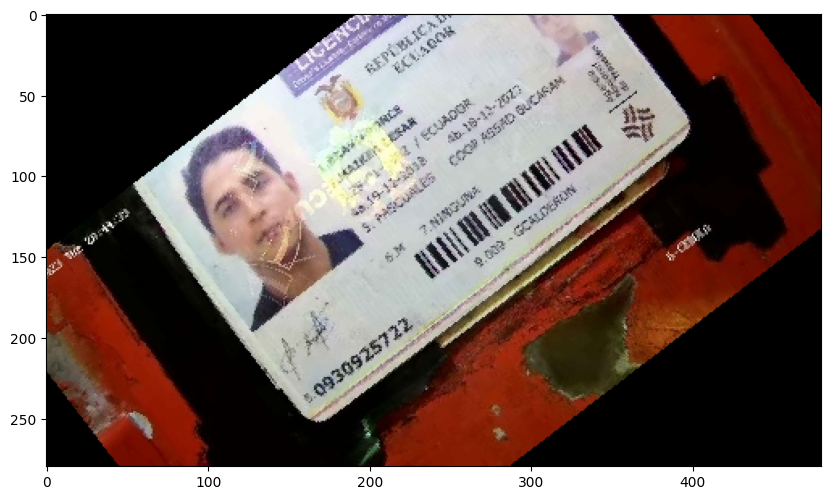

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.imshow(df["Matrix"][140])

In [13]:
from sklearn.model_selection import KFold,train_test_split

folder=KFold(n_splits=5)
X_train, X_test, y_train, y_test = train_test_split(
            df["Matrix"],
            df["Angle"],
            test_size=0.3,
            random_state=42,
            shuffle=True,
        )
kfolder = list(folder.split(X=X_train, y=y_train))
print(kfolder[0][1])

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import lightning as L
from PIL import Image

# --- Dataset adaptado ---
class DocumentOrientationDataset(Dataset):
    def __init__(self, annotations, transform=None):
        self.annotations = annotations
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        image = row["Matrix"]
        angle_deg = row["Angle"]
        angle_rad = math.radians(angle_deg)
        target = np.array([math.sin(angle_rad), math.cos(angle_rad)], dtype=np.float32)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(target)

# --- Transformaciones de imagen ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Modelo con Lightning ---
class OrientationModel(L.LightningModule):
    def __init__(self, lr=1e-4):
        super().__init__()
        self.lr=lr
        self.save_hyperparameters()
        base = models.mobilenet_v2(pretrained=True)
        num_features = base.classifier[1].in_features
        # Capas adicionales para mayor capacidad
        base.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
        )
        self.backbone = base
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        x = self.backbone(x)
        return nn.functional.normalize(x, dim=1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        error = self.angular_error(y_hat, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_angle_error", error, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

    def angular_error(self, preds, targets):
        dot = torch.sum(preds * targets, dim=1).clamp(-1.0, 1.0)
        angles = torch.acos(dot)
        return torch.mean(angles * 180.0 / math.pi)

# --- Preparación de datos (ajustar según tus datos) ---
train_dataset = DocumentOrientationDataset(df.iloc[kfolder[0][0]], transform=transform)
val_dataset = DocumentOrientationDataset(df.iloc[kfolder[0][1]], transform=transform)
batch=32
train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch)

# --- Entrenamiento ---
model = OrientationModel(lr=1e-4)
trainer = L.Trainer(max_epochs=30, accelerator="auto")
trainer.fit(model, train_loader, val_loader)


c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type        | Params | Mode 
-------------------------------

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\USER\.conda\envs\trabajo\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 1:  67%|██████▋   | 4/6 [00:06<00:03,  0.58it/s, v_num=2, val_loss=0.651, val_angle_error=60.60]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined